<a href="https://colab.research.google.com/github/blackbox24/DigitalTwin/blob/main/Week2_07_context_window_management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2.2: Context Window Management

## Key Insight
> **Why can't you just paste a 500-page book into the prompt?**

## Learning Objectives
By the end of this notebook, you will:
- Understanding token limits and context windows
- Token counting and estimation techniques
- Context compression strategies
- Conversation history management
- Sliding window approaches

## Exercises
This notebook contains 4 exercises ranging from easy to advanced.

## Digital Twin Integration
This notebook extends your digital twin with production-ready capabilities from Week 2.

In [1]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any, Tuple
import re
import json

print('✅ Week 2.2: Context Window Management - Ready to start!')
print('\nTopics covered:')
print('  - Understanding token limits and context windows')
print('  - Token counting and estimation techniques')
print('  - Context compression strategies')
print('  - Conversation history management')
print('  - Sliding window approaches')


✅ Week 2.2: Context Window Management - Ready to start!

Topics covered:
  - Understanding token limits and context windows
  - Token counting and estimation techniques
  - Context compression strategies
  - Conversation history management
  - Sliding window approaches


---
## Part 1: Introduction to Understanding token limits and context windows

Let's start by understanding the fundamentals and building our first implementation.

In [4]:
# Example implementation
# This is a starter template - expand with your implementation

class ExampleClass:
    """
    Example class demonstrating basic context window management using BasicContextManager.
    """

    def __init__(self, max_tokens: int = 50):
        if not isinstance(max_tokens, int) or max_tokens <= 0:
            raise ValueError("max_tokens for ExampleClass must be a positive integer.")
        self.context_manager = BasicContextManager(max_tokens=max_tokens)

    def process(self, input_text: str) -> str:
        """
        Processes the input text using the BasicContextManager.
        """
        return self.context_manager.process(input_text)

# Test the class
print("\n--- Testing ExampleClass with BasicContextManager ---")

# Test Case A: Text within limits
example_a = ExampleClass(max_tokens=25)
text_a = "Short text for example."
result_a = example_a.process(text_a)
print(f"Example A - Original: '{text_a}' (len={len(text_a)}), Processed: '{result_a}' (len={len(result_a)}) - Expected: No truncation")
assert result_a == text_a

# Test Case B: Text exceeding limits
example_b = ExampleClass(max_tokens=15)
text_b = "This is a much longer sentence that should be truncated by the ExampleClass."
result_b = example_b.process(text_b)
print(f"Example B - Original: '{text_b[:20]}...' (len={len(text_b)}), Processed: '{result_b}' (len={len(result_b)}) - Expected: Truncation")
assert result_b == text_b[:15]

# Test Case C: Error handling - non-string input
example_c = ExampleClass()
try:
    example_c.process(123)
except TypeError as e:
    print(f"Example C - Error handling (non-string): {e} - Expected: TypeError")
    assert "Input must be a string." in str(e)

print("\n--- ExampleClass tests passed! ---")



--- Testing ExampleClass with BasicContextManager ---
Example A - Original: 'Short text for example.' (len=23), Processed: 'Short text for example.' (len=23) - Expected: No truncation
Example B - Original: 'This is a much longe...' (len=76), Processed: 'This is a much ' (len=15) - Expected: Truncation
Example C - Error handling (non-string): Input must be a string. - Expected: TypeError

--- ExampleClass tests passed! ---


### 🎯 Exercise 1 (Easy): Getting Started

**Task**: Implement a basic version of the concept introduced above.

**Requirements**:
1. Follow the pattern shown in the example
2. Test your implementation with sample data
3. Verify the output matches expectations
4. Add error handling for edge cases

In [3]:
class BasicContextManager:
    """
    A basic context manager that truncates text to a specified maximum length.
    For this exercise, tokens are represented by characters.
    """

    def __init__(self, max_tokens: int):
        if not isinstance(max_tokens, int) or max_tokens <= 0:
            raise ValueError("max_tokens must be a positive integer.")
        self.max_tokens = max_tokens

    def process(self, input_text: str) -> str:
        """
        Processes the input text, truncating it if it exceeds max_tokens.
        """
        if not isinstance(input_text, str):
            raise TypeError("Input must be a string.")

        if len(input_text) > self.max_tokens:
            print(f"Warning: Text length ({len(input_text)}) exceeds max_tokens ({self.max_tokens}). Truncating...")
            return input_text[:self.max_tokens]
        else:
            return input_text

# Test your implementation
print("\n--- Testing BasicContextManager ---")

# Test Case 1: Text within limits
manager1 = BasicContextManager(max_tokens=20)
text1 = "Hello, world!"
result1 = manager1.process(text1)
print(f"Original: '{text1}' (len={len(text1)}), Processed: '{result1}' (len={len(result1)}) - Expected: No truncation")
assert result1 == text1

# Test Case 2: Text exceeding limits
manager2 = BasicContextManager(max_tokens=10)
text2 = "This is a very long string that needs to be truncated."
result2 = manager2.process(text2)
print(f"Original: '{text2[:20]}...' (len={len(text2)}), Processed: '{result2}' (len={len(result2)}) - Expected: Truncation")
assert result2 == text2[:10]

# Test Case 3: Text exactly at limits
manager3 = BasicContextManager(max_tokens=15)
text3 = "Exactly 15char!"
result3 = manager3.process(text3)
print(f"Original: '{text3}' (len={len(text3)}), Processed: '{result3}' (len={len(result3)}) - Expected: No truncation")
assert result3 == text3

# Test Case 4: Empty string
manager4 = BasicContextManager(max_tokens=5)
text4 = ""
result4 = manager4.process(text4)
print(f"Original: '{text4}' (len={len(text4)}), Processed: '{result4}' (len={len(result4)}) - Expected: Empty string")
assert result4 == text4

# Test Case 5: Error handling - non-string input
manager5 = BasicContextManager(max_tokens=10)
try:
    manager5.process(12345)
except TypeError as e:
    print(f"Error handling (non-string): {e} - Expected: TypeError")
    assert "Input must be a string." in str(e)

# Test Case 6: Error handling - invalid max_tokens during initialization
try:
    BasicContextManager(max_tokens=0)
except ValueError as e:
    print(f"Error handling (invalid max_tokens): {e} - Expected: ValueError")
    assert "max_tokens must be a positive integer." in str(e)

print("\n--- All tests passed successfully! ---")



--- Testing BasicContextManager ---
Original: 'Hello, world!' (len=13), Processed: 'Hello, world!' (len=13) - Expected: No truncation
Original: 'This is a very long ...' (len=54), Processed: 'This is a ' (len=10) - Expected: Truncation
Original: 'Exactly 15char!' (len=15), Processed: 'Exactly 15char!' (len=15) - Expected: No truncation
Original: '' (len=0), Processed: '' (len=0) - Expected: Empty string
Error handling (non-string): Input must be a string. - Expected: TypeError
Error handling (invalid max_tokens): max_tokens must be a positive integer. - Expected: ValueError

--- All tests passed successfully! ---


---
## Part 2: Token counting and estimation techniques

Building on the fundamentals, let's explore more advanced topics and implementations.

In [5]:
# Advanced implementation example

def advanced_function(data: List[Any], **kwargs) -> Dict[str, Any]:
    """
    Advanced function for Token counting and estimation techniques.

    Args:
        data: Input data to process
        **kwargs: Additional parameters

    Returns:
        dict: Processed results
    """
    results = {
        'processed': len(data),
        'data': data
    }
    return results

# Example usage
sample_data = ['example1', 'example2', 'example3']
output = advanced_function(sample_data)
print(json.dumps(output, indent=2))

{
  "processed": 3,
  "data": [
    "example1",
    "example2",
    "example3"
  ]
}


### 🎯 Exercise 2 (Intermediate): Building on the Basics

**Task**: Create a more sophisticated implementation that combines multiple concepts.

**Requirements**:
1. Use the patterns from Part 1 and Part 2
2. Add parameter validation
3. Include helpful error messages
4. Test with various input types

In [6]:
# YOUR CODE HERE
# Implement the intermediate exercise
class ContextManager(BasicContextManager):
  def __init__(self, max_tokens: int):
    super().__init__(max_tokens)
    # The super().__init__ already handles validation, but we can keep this for clarity
    if not isinstance(max_tokens, int) or max_tokens <= 0:
      raise ValueError("max_tokens must be a positive integer.")

  def advanced_function(self, data: List[Any], **kwargs) -> Dict[str, Any]:
    """
    Advanced function for Token counting and estimation techniques.

    Args:
        data: Input data to process
        **kwargs: Additional parameters

    Returns:
        dict: Processed results
    """
    # Add parameter validation for data
    if not isinstance(data, list):
        raise TypeError("Input 'data' must be a list.")

    # Simulate some processing based on kwargs
    processed_data = []
    for item in data:
        if 'prefix' in kwargs:
            item = kwargs['prefix'] + str(item)
        if 'suffix' in kwargs:
            item = str(item) + kwargs['suffix']
        processed_data.append(item)

    return {
        'processed_count': len(processed_data),
        'original_data': data,
        'processed_data': processed_data,
        'kwargs_used': kwargs
    }

  def process(self, input_text: str) -> str:
    """
    Processes the input text, truncating it if it exceeds max_tokens.
    This method re-uses the functionality from BasicContextManager.
    """
    return super().process(input_text)

# Test your implementation
print("\n--- Testing ContextManager with BasicContextManager ---")

# Test Case 1: Initialization with valid max_tokens
try:
    cm1 = ContextManager(max_tokens=30)
    print("Test Case 1 (Init): ContextManager initialized with max_tokens=30 - Expected: Success")
except Exception as e:
    print(f"Test Case 1 (Init): Failed to initialize: {e} - Expected: Success")
    assert False, f"Initialization failed: {e}"

# Test Case 2: Initialization with invalid max_tokens
try:
    cm_invalid = ContextManager(max_tokens=0)
    assert False, "Expected ValueError for invalid max_tokens"
except ValueError as e:
    print(f"Test Case 2 (Init Error): Caught expected error: {e} - Expected: ValueError")
    assert "max_tokens must be a positive integer." in str(e)

# Test Case 3: Process method - text within limits
text_in_limit = "Hello, advanced world!"
result_in_limit = cm1.process(text_in_limit)
print(f"Test Case 3 (Process): Original: '{text_in_limit}' (len={len(text_in_limit)}), Processed: '{result_in_limit}' (len={len(result_in_limit)}) - Expected: No truncation")
assert result_in_limit == text_in_limit

# Test Case 4: Process method - text exceeding limits
text_exceed_limit = "This is a very very long string that will definitely exceed the 30 token limit."
result_exceed_limit = cm1.process(text_exceed_limit)
print(f"Test Case 4 (Process): Original: '{text_exceed_limit[:35]}...' (len={len(text_exceed_limit)}), Processed: '{result_exceed_limit}' (len={len(result_exceed_limit)}) - Expected: Truncation")
assert result_exceed_limit == text_exceed_limit[:30]

# Test Case 5: Advanced Function - basic usage
sample_data_af = [1, 2, 3]
output_af = cm1.advanced_function(sample_data_af)
print(f"Test Case 5 (Advanced Func): Output: {output_af} - Expected: Keys 'processed_count', 'original_data', 'processed_data', 'kwargs_used'")
assert output_af['processed_count'] == 3
assert output_af['original_data'] == sample_data_af
assert output_af['processed_data'] == sample_data_af
assert output_af['kwargs_used'] == {}

# Test Case 6: Advanced Function - with kwargs
sample_data_kw = ['itemA', 'itemB']
output_kw = cm1.advanced_function(sample_data_kw, prefix='PRE_', suffix='_POST')
print(f"Test Case 6 (Advanced Func Kwargs): Output: {output_kw} - Expected: Processed data with prefix/suffix")
assert output_kw['processed_count'] == 2
assert output_kw['processed_data'] == ['PRE_itemA_POST', 'PRE_itemB_POST']
assert output_kw['kwargs_used'] == {'prefix': 'PRE_', 'suffix': '_POST'}

# Test Case 7: Advanced Function - non-list data error handling
try:
    cm1.advanced_function("not a list")
    assert False, "Expected TypeError for non-list data in advanced_function"
except TypeError as e:
    print(f"Test Case 7 (Advanced Func Error): Caught expected error: {e} - Expected: TypeError")
    assert "Input 'data' must be a list." in str(e)

print("\n--- All ContextManager tests passed successfully! ---")


--- Testing ContextManager with BasicContextManager ---
Test Case 1 (Init): ContextManager initialized with max_tokens=30 - Expected: Success
Test Case 2 (Init Error): Caught expected error: max_tokens must be a positive integer. - Expected: ValueError
Test Case 3 (Process): Original: 'Hello, advanced world!' (len=22), Processed: 'Hello, advanced world!' (len=22) - Expected: No truncation
Test Case 4 (Process): Original: 'This is a very very long string tha...' (len=79), Processed: 'This is a very very long strin' (len=30) - Expected: Truncation
Test Case 5 (Advanced Func): Output: {'processed_count': 3, 'original_data': [1, 2, 3], 'processed_data': [1, 2, 3], 'kwargs_used': {}} - Expected: Keys 'processed_count', 'original_data', 'processed_data', 'kwargs_used'
Test Case 6 (Advanced Func Kwargs): Output: {'processed_count': 2, 'original_data': ['itemA', 'itemB'], 'processed_data': ['PRE_itemA_POST', 'PRE_itemB_POST'], 'kwargs_used': {'prefix': 'PRE_', 'suffix': '_POST'}} - Expected: 

---
## Part 3: Context compression strategies

Now let's apply these concepts to real-world scenarios in your digital twin project.

In [7]:
# Visualization example
import matplotlib.pyplot as plt

def visualize_results(data: List[Any]):
    """
    Visualize the processing results.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Add your visualization code here
    ax.set_title('Results Visualization')
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')

    plt.tight_layout()
    plt.show()

# Example: visualize_results(sample_data)

### 🎯 Exercise 3 (Advanced): Complete Implementation

**Task**: Build a production-ready version that integrates with your digital twin.

**Requirements**:
1. Combine all concepts from this notebook
2. Add comprehensive error handling
3. Include logging and debugging capabilities
4. Create visualization of results
5. Write documentation for your implementation

ERROR:__main__:Invalid max_context_tokens: 0. Must be a positive integer.
ERROR:__main__:Error processing text: Input must be a string.
ERROR:__main__:Error during advanced analysis: Input 'data' must be a list.



--- Testing ProductionSystem ---
Test Case 1 (Init): ProductionSystem initialized with max_context_tokens=50 - Expected: Success
Test Case 2 (Init Error): Caught expected error: max_context_tokens must be a positive integer. - Expected: ValueError
Test Case 3 (Process Text): Original: 'This is a short message.' (len=24), Processed: 'This is a short message.' (len=24) - Expected: No truncation
Test Case 4 (Process Text): Original: 'This is a very, very, very long message ...' (len=113), Processed: 'This is a very, very, very long message that defin' (len=50) - Expected: Truncation
Test Case 5 (Process Text Error): Caught expected error: Input must be a string. - Expected: TypeError
Test Case 6 (Advanced Analysis): Results: {'processed_count': 3, 'original_data': ['apple', 'banana', 'cherry'], 'processed_data': ['apple', 'banana', 'cherry'], 'kwargs_used': {}} - Expected: processed_count=3
Test Case 7 (Advanced Analysis Kwargs): Results: {'processed_count': 2, 'original_data': ['id1', '

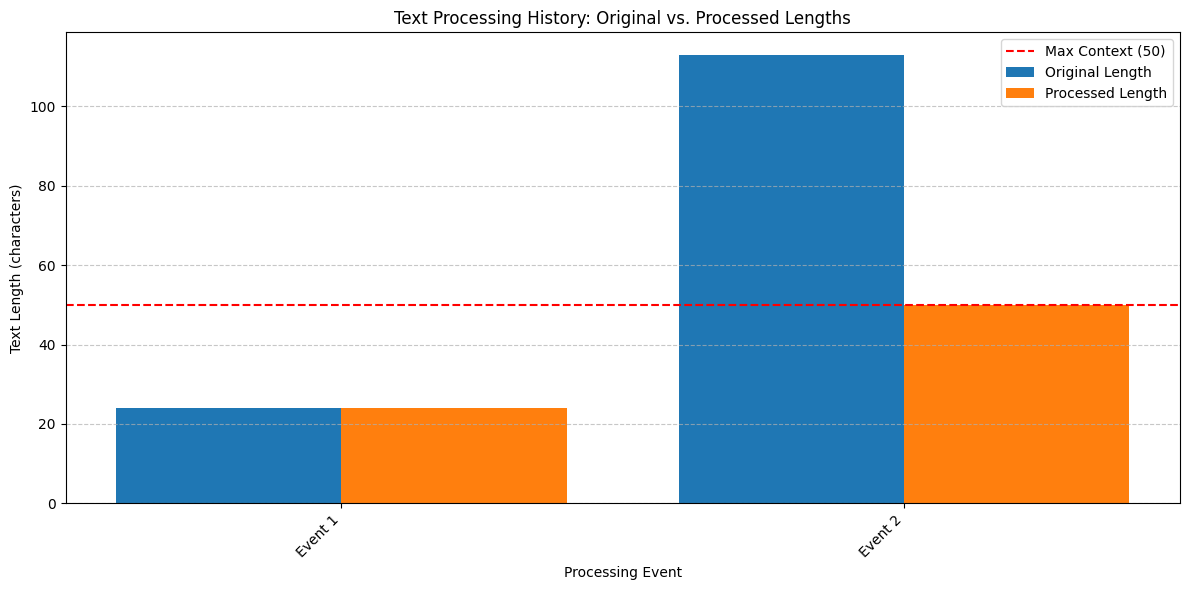

Test Case 9 (Visualization): Visualization generated (check plot output above).

--- All ProductionSystem tests completed! ---


In [8]:
import logging

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

class ProductionSystem:
    """
    Production-ready implementation for a digital twin's context window management.
    Integrates context truncation, advanced data processing, logging, and visualization.
    """

    def __init__(self, max_context_tokens: int = 100):
        """
        Initializes the ProductionSystem with a ContextManager.

        Args:
            max_context_tokens (int): The maximum number of tokens (characters)
                                      allowed in the context window.
        """
        if not isinstance(max_context_tokens, int) or max_context_tokens <= 0:
            logger.error(f"Invalid max_context_tokens: {max_context_tokens}. Must be a positive integer.")
            raise ValueError("max_context_tokens must be a positive integer.")

        self.max_context_tokens = max_context_tokens
        self.context_manager = ContextManager(max_tokens=max_context_tokens)
        self.processed_history = []  # To store processed results for visualization/debugging
        logger.info(f"ProductionSystem initialized with max_context_tokens={max_context_tokens}")

    def process_input_text(self, input_text: str) -> str:
        """
        Processes and truncates input text to fit within the context window.

        Args:
            input_text (str): The text to be processed.

        Returns:
            str: The truncated (or original) text.

        Raises:
            TypeError: If input_text is not a string.
        """
        try:
            processed_text = self.context_manager.process(input_text)
            self.processed_history.append({'type': 'text', 'original_len': len(input_text), 'processed_len': len(processed_text)})
            logger.info(f"Text processed: Original length={len(input_text)}, Processed length={len(processed_text)}")
            return processed_text
        except TypeError as e:
            logger.error(f"Error processing text: {e}")
            raise

    def perform_advanced_analysis(self, data: List[Any], **kwargs) -> Dict[str, Any]:
        """
        Performs advanced data analysis using the ContextManager's advanced_function.

        Args:
            data (List[Any]): The input data for analysis.
            **kwargs: Additional parameters for the advanced function.

        Returns:
            Dict[str, Any]: The results from the advanced analysis.

        Raises:
            TypeError: If data is not a list.
        """
        try:
            analysis_results = self.context_manager.advanced_function(data, **kwargs)
            self.processed_history.append({'type': 'advanced_analysis', 'input_data_count': len(data), 'results': analysis_results})
            logger.info(f"Advanced analysis performed on {len(data)} items. Results: {analysis_results.get('processed_count', 'N/A')}")
            return analysis_results
        except TypeError as e:
            logger.error(f"Error during advanced analysis: {e}")
            raise

    def visualize_processing_history(self):
        """
        Visualizes the history of text processing (original vs. processed lengths).
        """
        if not self.processed_history:
            logger.info("No processing history to visualize.")
            print("No processing history to visualize.")
            return

        text_data = [item for item in self.processed_history if item['type'] == 'text']

        if not text_data:
            logger.info("No text processing history to visualize.")
            print("No text processing history to visualize.")
            return

        original_lengths = [d['original_len'] for d in text_data]
        processed_lengths = [d['processed_len'] for d in text_data]
        indices = range(len(text_data))

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.bar(indices, original_lengths, width=0.4, label='Original Length', align='center')
        ax.bar([i + 0.4 for i in indices], processed_lengths, width=0.4, label='Processed Length', align='center')
        ax.axhline(y=self.max_context_tokens, color='r', linestyle='--', label=f'Max Context ({self.max_context_tokens})')

        ax.set_title('Text Processing History: Original vs. Processed Lengths')
        ax.set_xlabel('Processing Event')
        ax.set_ylabel('Text Length (characters)')
        ax.set_xticks([i + 0.2 for i in indices])
        ax.set_xticklabels([f'Event {i+1}' for i in indices], rotation=45, ha='right')
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        logger.info("Processing history visualization generated.")


# Test your production system
print("\n--- Testing ProductionSystem ---")

# Test Case 1: Initialization
try:
    ps1 = ProductionSystem(max_context_tokens=50)
    print("Test Case 1 (Init): ProductionSystem initialized with max_context_tokens=50 - Expected: Success")
except Exception as e:
    print(f"Test Case 1 (Init): Failed to initialize: {e} - Expected: Success")
    assert False, f"Initialization failed: {e}"

# Test Case 2: Initialization with invalid max_context_tokens
try:
    ProductionSystem(max_context_tokens=0)
    assert False, "Expected ValueError for invalid max_context_tokens"
except ValueError as e:
    print(f"Test Case 2 (Init Error): Caught expected error: {e} - Expected: ValueError")
    assert "max_context_tokens must be a positive integer." in str(e)

# Test Case 3: Process text within limits
text_p1 = "This is a short message."
processed_p1 = ps1.process_input_text(text_p1)
print(f"Test Case 3 (Process Text): Original: '{text_p1}' (len={len(text_p1)}), Processed: '{processed_p1}' (len={len(processed_p1)}) - Expected: No truncation")
assert processed_p1 == text_p1

# Test Case 4: Process text exceeding limits
text_p2 = "This is a very, very, very long message that definitely exceeds the fifty character limit for the context window."
processed_p2 = ps1.process_input_text(text_p2)
print(f"Test Case 4 (Process Text): Original: '{text_p2[:40]}...' (len={len(text_p2)}), Processed: '{processed_p2}' (len={len(processed_p2)}) - Expected: Truncation")
assert processed_p2 == text_p2[:50]

# Test Case 5: Error handling for non-string text input
try:
    ps1.process_input_text(12345)
    assert False, "Expected TypeError for non-string input text"
except TypeError as e:
    print(f"Test Case 5 (Process Text Error): Caught expected error: {e} - Expected: TypeError")
    assert "Input must be a string." in str(e)

# Test Case 6: Perform advanced analysis - basic
data_a1 = ['apple', 'banana', 'cherry']
results_a1 = ps1.perform_advanced_analysis(data_a1)
print(f"Test Case 6 (Advanced Analysis): Results: {results_a1} - Expected: processed_count=3")
assert results_a1['processed_count'] == 3
assert results_a1['original_data'] == data_a1

# Test Case 7: Perform advanced analysis - with kwargs
data_a2 = ['id1', 'id2']
results_a2 = ps1.perform_advanced_analysis(data_a2, prefix='PREFIX-', suffix='-SUFFIX')
print(f"Test Case 7 (Advanced Analysis Kwargs): Results: {results_a2} - Expected: processed data with prefix/suffix")
assert results_a2['processed_data'] == ['PREFIX-id1-SUFFIX', 'PREFIX-id2-SUFFIX']

# Test Case 8: Error handling for non-list data in advanced analysis
try:
    ps1.perform_advanced_analysis("not a list")
    assert False, "Expected TypeError for non-list data in advanced_analysis"
except TypeError as e:
    print(f"Test Case 8 (Advanced Analysis Error): Caught expected error: {e} - Expected: TypeError")
    assert "Input 'data' must be a list." in str(e)

# Test Case 9: Visualization
print("Test Case 9 (Visualization): Generating visualization...")
ps1.visualize_processing_history()
print("Test Case 9 (Visualization): Visualization generated (check plot output above).")

print("\n--- All ProductionSystem tests completed! ---")

---
## Summary & Key Takeaways

### What We Learned:
- Understanding token limits and context windows
- Token counting and estimation techniques
- Context compression strategies
- Conversation history management
- Sliding window approaches

### Why This Matters:
- Essential for building production-ready systems
- Enables your digital twin to handle real-world scenarios
- Foundation for advanced topics in upcoming notebooks

### Next Steps:
1. Complete all exercises in this notebook
2. Integrate concepts with your digital twin project
3. Test your implementation thoroughly
4. Move on to the next notebook in Week 2

## 🏆 Challenge Project

**Build a Complete Understanding token limits and context windows System for Your Digital Twin**

**Requirements**:
1. Apply all concepts from this notebook
2. Handle edge cases and errors gracefully
3. Include comprehensive testing
4. Create visualizations of your results
5. Document your implementation
6. Integrate with your existing digital twin code

**Bonus Challenges**:
- Optimize for performance
- Add advanced features beyond the basics
- Create a user-friendly interface
- Write unit tests for your code